In [111]:
## Cleaning
import pandas as pd
import re
import datetime
import ast
import math

# KMeans
from sklearn.cluster import KMeans

# Kmedoids
from sklearn_extra.cluster import KMedoids

# Global
import pickle
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from tabulate import tabulate
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer


## Cleaning Bulan Desember dan November

In [112]:
##Load File Gempa pada bulan November dan Desember tahun 2023 yang masih kotor

des_nov = [
    pd.read_csv('./datasets/gempa_bumi_desember_dirty.csv'), 
    pd.read_csv('./datasets/gempa_bumi_desember_dirty.csv')
]

In [113]:
##Untuk menghapus data duplikat yang memiliki string UPDATE dan langsung akan dihapus

for i in range(len(des_nov)):
    des_nov[i] = des_nov[i].rename(columns={'created_at;id_str;full_text;quote_count;reply_count;retweet_count;favorite_count;lang;user_id_str;conversation_id_str;username;tweet_url': 'Unnamed: 0'})
    index = des_nov[i][des_nov[i]['Unnamed: 0'].str.contains('UPDATE')].index
    des_nov[i].drop(index, inplace=True)

des_nov

[                                            Unnamed: 0  \
 0    Sun Dec 31 23:18:11 +0000 2023;174159966158732...   
 1    Sun Dec 31 07:38:09 +0000 2023;174136309376948...   
 2    Sun Dec 31 05:48:08 +0000 2023;174133540656896...   
 4    Sun Dec 31 05:11:40 +0000 2023;174132623155831...   
 5    Sun Dec 31 04:55:37 +0000 2023;174132219405416...   
 ..                                                 ...   
 822  Fri Dec 01 04:22:09 +0000 2023;173044213503454...   
 823  Fri Dec 01 02:35:09 +0000 2023;173041520660885...   
 824  Fri Dec 01 01:46:10 +0000 2023;173040287832879...   
 825  Fri Dec 01 01:11:08 +0000 2023;173039406279104...   
 827  Fri Dec 01 00:36:41 +0000 2023;173038539199444...   
 
                    Unnamed: 1                 Unnamed: 2  \
 0     01-Jan-2024 06:11:23WIB                 Lok:1.89LS   
 1     31-Dec-2023 14:35:34WIB                 Lok:6.84LS   
 2     31-Dec-2023 12:43:38WIB                 Lok:6.74LS   
 4            Kedalaman: 10 km   31 Des 2023 1

In [114]:
clean = []

for i in range(len(des_nov)):
    temp = des_nov[i].drop(['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'], axis=1)
    clean.append(temp.dropna())
    
clean

[                                            Unnamed: 0  \
 0    Sun Dec 31 23:18:11 +0000 2023;174159966158732...   
 1    Sun Dec 31 07:38:09 +0000 2023;174136309376948...   
 2    Sun Dec 31 05:48:08 +0000 2023;174133540656896...   
 5    Sun Dec 31 04:55:37 +0000 2023;174132219405416...   
 7    Sun Dec 31 04:55:14 +0000 2023;174132209519445...   
 ..                                                 ...   
 821  Fri Dec 01 04:58:08 +0000 2023;173045119065441...   
 822  Fri Dec 01 04:22:09 +0000 2023;173044213503454...   
 823  Fri Dec 01 02:35:09 +0000 2023;173041520660885...   
 824  Fri Dec 01 01:46:10 +0000 2023;173040287832879...   
 825  Fri Dec 01 01:11:08 +0000 2023;173039406279104...   
 
                    Unnamed: 1    Unnamed: 2  \
 0     01-Jan-2024 06:11:23WIB    Lok:1.89LS   
 1     31-Dec-2023 14:35:34WIB    Lok:6.84LS   
 2     31-Dec-2023 12:43:38WIB    Lok:6.74LS   
 5      31-Des-23 11:52:34 WIB   Lok:8.22 LS   
 7     31-Dec-2023 11:52:33WIB    Lok:8.25LS   
 .

In [115]:
def split_rad(text):
    rad = re.search(r"\((.*?)\)", text)

    if rad is not None:
        temp =  rad.group(1).split()
        return temp[0]
    return "delete"

def split_prov(text):
    prov = re.search(r"\((.*?)\)", text)

    if prov is not None: 
        newText = prov.group(1)
        split = newText.split()
        temp = split[-1].split('-')
        
        return temp[-1]
    return "delete"

def split_mag(text):
    mag = re.search(r"(\d+\.\d+)\s*(Mag(?:nitudo)?)?", text)

    return mag.group(1)

def split_depth(text):   
    depth = re.search(r":\s*(\d+)", str(text))

    return depth.group(1)

def split_lat(text):
    return text.replace("Lok:", "")

def split_lon(text):
    return text.split()[0]

In [116]:
nov_des = pd.DataFrame()

for i in range(len(clean)):
    mag = clean[i][:]["Unnamed: 0"].apply(split_mag)
    depth = clean[i][:]["Unnamed: 4"].apply(split_depth)
    rad = clean[i][:]["Unnamed: 3"].apply(split_rad)
    prov = clean[i][:]["Unnamed: 3"].apply(split_prov)
    lat = clean[i][:]["Unnamed: 2"].apply(split_lat)
    lon = clean[i][:]["Unnamed: 3"].apply(split_lon)
 
    nov_des["mag"] = mag
    nov_des["depth"] = depth
    nov_des["rad"] = rad
    nov_des["prov"] = prov
    nov_des["lat"] = lat
    nov_des["lon"] = lon

nov_des

,mag,depth,rad,prov,lat,lon
0,2.9,10,85,SULTENG,1.89LS,122.53BT
1,4.1,10,2,JABAR,6.84LS,107.93BT
2,2.9,10,27,JABAR,6.74LS,106.60BT
5,5.0,10,90,JABAR,8.22 LS,107.87
7,5.0,10,93,JABAR,8.25LS,107.86BT
...,...,...,...,...,...,...
821,3.2,10,29,ACEHTENGAH,4.54LU,96.59BT
822,2.9,10,107,SULUT,1.78LU,122.85BT
823,4.4,386,187,MALUKUBRTDAYA,6.47LS,127.97BT
824,3.1,24,69,MALUT,1.39LU,126.93BT


## Cleaning Jan-April

In [117]:
def extract_quake_data(text):
    lon = None
    lat = None
    
    magnitude = re.search(r"Mag:(\d+\.\d+)", text).group(1)
    location = re.search(r"\((.+?)\)", text).group(1)
    depth = re.search(r"Kedlmn:(\d+)", text).group(1)
    prov = location.split()[-1].split('-')[-1]
    rad = location.split()[0]
    
    pattern = r"Lok:(\d+\.\d+\w+)\s+(\d+\.\d+)\w+"
    match = re.search(pattern, text)
    
    if match:
        lat = match.group(1)
        
        lon_str = match.group(0)
        lon = lon_str.split(" ")[1]

    quake_data = {
        "mag": magnitude,
        "depth": depth,
        "rad": rad,
        "prov": prov,
        "lat": lat,
        "lon": lon
    }

    return quake_data

In [118]:
month_dirty = [
    pd.read_csv('./datasets/gempa_bumi_januari.csv'),
    pd.read_csv('./datasets/gempa_bumi_februari.csv'), 
    pd.read_csv('./datasets/gempa_bumi_maret.csv'),
    pd.read_csv('./datasets/gempa_bumi_april.csv')
]

month_clean = [  
]

for i in range(len(month_dirty)):
    cleaned = month_dirty[i][:]["full_text"].apply(extract_quake_data)
    month_clean.append(cleaned)

data_janap = pd.concat(month_clean)
data_janap = pd.DataFrame(data_janap.tolist())
data_janap

,mag,depth,rad,prov,lat,lon
0,3.6,10,74,PAPUABRT,3.92LS,133.71BT
1,2.6,164,3,SUMUT,1.49LU,99.64BT
2,4.5,182,165,MALUKUTENGAH,4.60LS,129.69BT
3,3.2,10,116,JABAR,8.50LS,107.82BT
4,5.0,11,129,MALUT,1.96LU,126.60BT
...,...,...,...,...,...,...
1311,2.9,10,30,SULTENG,2.66LS,121.63BT
1312,3.7,10,137,JATIM,5.80LS,112.60BT
1313,3.0,10,26,SULSEL,3.53LS,120.32BT
1314,3.6,10,115,JATIM,5.96LS,112.49BT


## Gabungkan Dataset

In [119]:
data = pd.concat([data_janap, nov_des])
data = data.dropna()
data

,mag,depth,rad,prov,lat,lon
0,3.6,10,74,PAPUABRT,3.92LS,133.71BT
1,2.6,164,3,SUMUT,1.49LU,99.64BT
2,4.5,182,165,MALUKUTENGAH,4.60LS,129.69BT
3,3.2,10,116,JABAR,8.50LS,107.82BT
4,5.0,11,129,MALUT,1.96LU,126.60BT
...,...,...,...,...,...,...
821,3.2,10,29,ACEHTENGAH,4.54LU,96.59BT
822,2.9,10,107,SULUT,1.78LU,122.85BT
823,4.4,386,187,MALUKUBRTDAYA,6.47LS,127.97BT
824,3.1,24,69,MALUT,1.39LU,126.93BT


## Transformasi Data

In [120]:
def makeLatitude(text):
    lat = float(text[:-2])
    pattern = r"(LS|LU)"
    match = re.search(pattern, text)

    if match:
        if match.group(1) == "LS":
            lat = -1 * float(text[:-2])
        
        return abs(lat) if lat >= 0 else -abs(lat)

def makeLongitude(text):
    lon = float(text[:-2])
    pattern = r"(BT|BB)"
    match = re.search(pattern, text)

    if match:
        if match.group(1) == "BB":
            lon = -1 * float(text[:-2])
        
        return abs(lon) if lon >= 0 else -abs(lon)

In [121]:
data['lat'] = data[:]['lat'].apply(makeLatitude)
data['lon'] = data[:]['lon'].apply(makeLongitude)

data

,mag,depth,rad,prov,lat,lon
0,3.6,10,74,PAPUABRT,-3.92,133.71
1,2.6,164,3,SUMUT,1.49,99.64
2,4.5,182,165,MALUKUTENGAH,-4.60,129.69
3,3.2,10,116,JABAR,-8.50,107.82
4,5.0,11,129,MALUT,1.96,126.60
...,...,...,...,...,...,...
821,3.2,10,29,ACEHTENGAH,4.54,96.59
822,2.9,10,107,SULUT,1.78,122.85
823,4.4,386,187,MALUKUBRTDAYA,-6.47,127.97
824,3.1,24,69,MALUT,1.39,126.93


In [122]:
data = data.dropna()
data

,mag,depth,rad,prov,lat,lon
0,3.6,10,74,PAPUABRT,-3.92,133.71
1,2.6,164,3,SUMUT,1.49,99.64
2,4.5,182,165,MALUKUTENGAH,-4.60,129.69
3,3.2,10,116,JABAR,-8.50,107.82
4,5.0,11,129,MALUT,1.96,126.60
...,...,...,...,...,...,...
821,3.2,10,29,ACEHTENGAH,4.54,96.59
822,2.9,10,107,SULUT,1.78,122.85
823,4.4,386,187,MALUKUBRTDAYA,-6.47,127.97
824,3.1,24,69,MALUT,1.39,126.93


In [123]:
def encoded_loc(row, encode):
    if row['prov'] in encode:
        return encode[row['prov']]

    return None

unique_locs = data['prov'].unique()
mapLoc = {prov: i + 1 for i, prov in enumerate(unique_locs)}

data['prov_enco'] = data['prov'].map(mapLoc)
data

/tmp/ipykernel_22032/3138881448.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['prov_enco'] = data['prov'].map(mapLoc)


,mag,depth,rad,prov,lat,lon,prov_enco
0,3.6,10,74,PAPUABRT,-3.92,133.71,1
1,2.6,164,3,SUMUT,1.49,99.64,2
2,4.5,182,165,MALUKUTENGAH,-4.60,129.69,3
3,3.2,10,116,JABAR,-8.50,107.82,4
4,5.0,11,129,MALUT,1.96,126.60,5
...,...,...,...,...,...,...,...
821,3.2,10,29,ACEHTENGAH,4.54,96.59,9
822,2.9,10,107,SULUT,1.78,122.85,15
823,4.4,386,187,MALUKUBRTDAYA,-6.47,127.97,14
824,3.1,24,69,MALUT,1.39,126.93,5


In [124]:
x = data[['mag', 'depth', 'rad', 'prov_enco']]
x

,mag,depth,rad,prov_enco
0,3.6,10,74,1
1,2.6,164,3,2
2,4.5,182,165,3
3,3.2,10,116,4
4,5.0,11,129,5
...,...,...,...,...
821,3.2,10,29,9
822,2.9,10,107,15
823,4.4,386,187,14
824,3.1,24,69,5


## Normalisasi Data

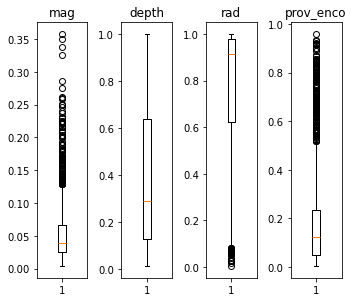

In [125]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

plt.figure(figsize=(12, 8))
for i, column in enumerate (dataScaled.columns, 1):
    plt.subplot(2, 10, i)
    plt.boxplot(dataScaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

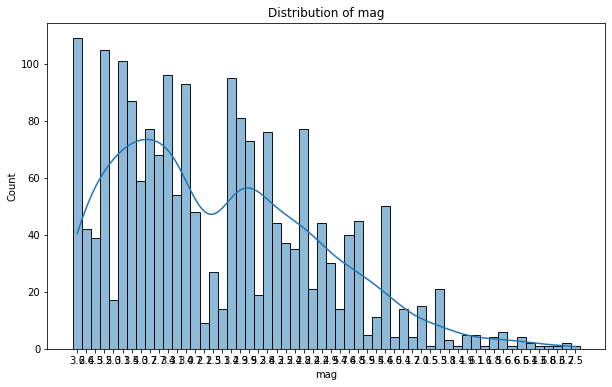

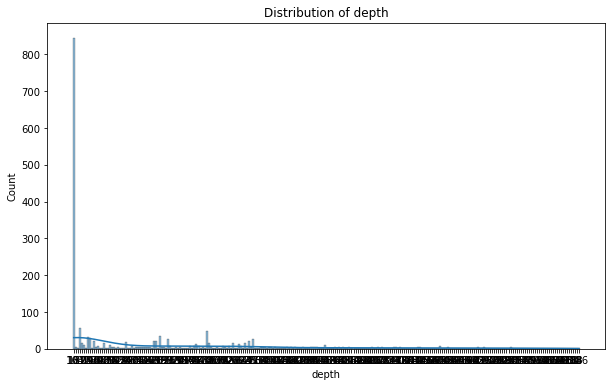

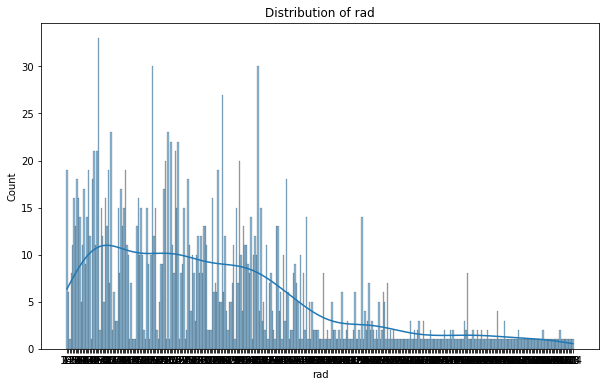

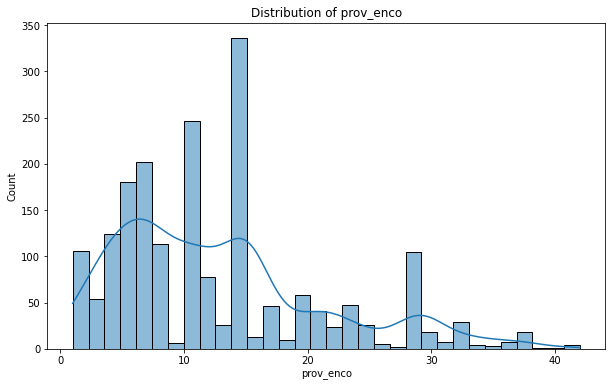

In [126]:
for column in dataScaled.columns[:6]:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

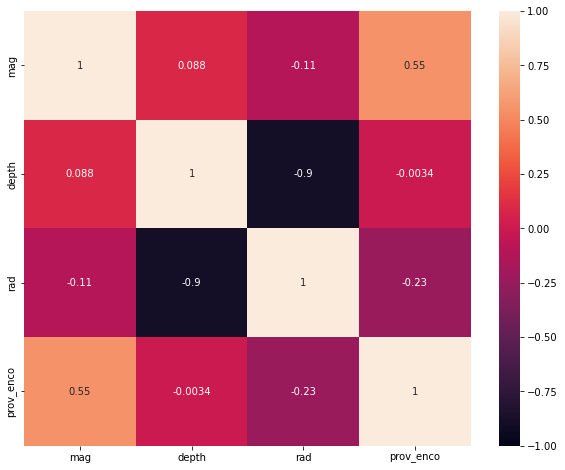

In [127]:
correlation = dataScaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)
plt.show()

## K-Means

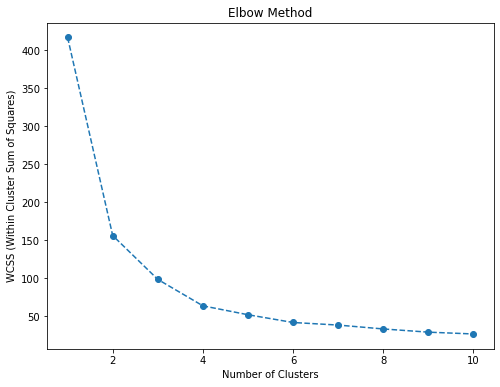

In [128]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(dataScaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [129]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

3

In [130]:
kmeans = KMeans(n_clusters=cluster_knee.elbow, random_state=42)
predict_kmeans = kmeans.fit(dataScaled)
predict_kmeans.cluster_centers_

array([[0.04312058, 0.18028302, 0.96206997, 0.12235643],
       [0.03731538, 0.90663667, 0.33597728, 0.10824948],
       [0.09329756, 0.47600876, 0.67600954, 0.43177469]])

In [131]:
data['kmeans'] = predict_kmeans.labels_
data['kmeans'].value_counts()

/tmp/ipykernel_22032/376390094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmeans'] = predict_kmeans.labels_


kmeans
0    1124
1     416
2     399
Name: count, dtype: int64

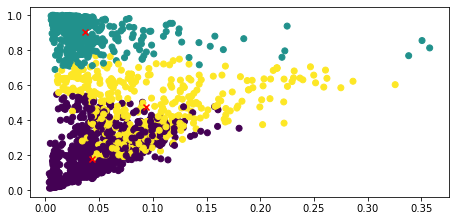

In [132]:
kmeans_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmeans_data[:, 0], kmeans_data[:, 1], c=predict_kmeans.labels_, cmap='viridis')
plt.scatter(predict_kmeans.cluster_centers_[:, 0], predict_kmeans.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

## K-Medoids

/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/home/nexus/miniconda3/envs/myJupyter/lib/python3.9/site-packages/sklearn_extra/cluster/_k_medoids.py:275: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(


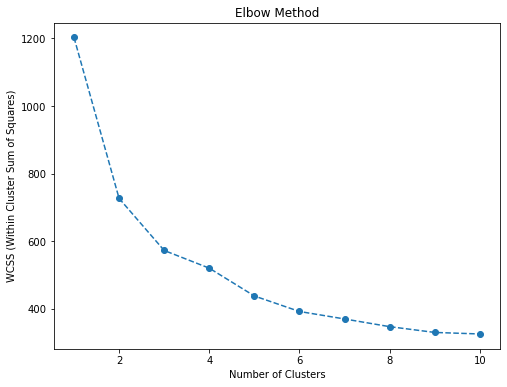

In [133]:
wcss = []

for i in range(1, 11):
    kMedoids = KMedoids(metric="manhattan", n_clusters=i, method='alternate', random_state=42)
    kMedoids.fit(dataScaled)
    wcss.append(kMedoids.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [134]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

3

In [135]:
kMedoids = KMedoids(n_clusters=cluster_knee.elbow, method='alternate', random_state=42)
predict_kmedoids = kMedoids.fit(dataScaled)
kMedoids.cluster_centers_

array([[0.03301291, 0.11004304, 0.99038732, 0.07703012],
       [0.04087099, 0.93573058, 0.33342124, 0.10755524],
       [0.08642716, 0.38892223, 0.88587842, 0.2376747 ]])

In [136]:
data['kmedoids'] = predict_kmedoids.labels_
data['kmedoids'].value_counts()

/tmp/ipykernel_22032/3650528949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmedoids'] = predict_kmedoids.labels_


kmedoids
0    826
2    668
1    445
Name: count, dtype: int64

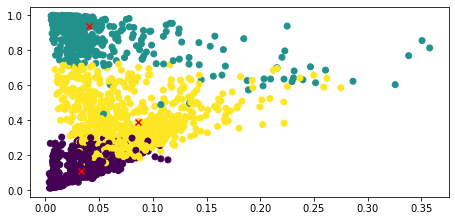

In [137]:
kmedoids_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmedoids_data[:, 0], kmedoids_data[:, 1], c=predict_kmedoids.labels_, cmap='viridis')
plt.scatter(predict_kmedoids.cluster_centers_[:, 0], predict_kmedoids.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

## Pengujian Silhoutte Coefficient

In [138]:
from tabulate import tabulate

avg_kmeans = silhouette_score(dataScaled, predict_kmeans.labels_)
avg_kmedoids = silhouette_score(dataScaled, predict_kmedoids.labels_)

avg = pd.DataFrame([{"K-Means": avg_kmeans, "K-Medoids": avg_kmedoids}])

print(tabulate(avg, headers='keys', tablefmt='grid', showindex=False))

+-----------+-------------+
|   K-Means |   K-Medoids |
+===========+=============+
|  0.540487 |    0.458545 |
+-----------+-------------+


In [139]:
# data.to_csv('dataset-with-label.csv', index=False)

## Centroid

In [141]:
labels_cluster = [0, 1, 2]
labels_data = ['mag', 'depth', 'rad', 'prov_enco']
centroid_kmeans = pd.DataFrame()

for index in labels_cluster:
    for label_data in labels_data:
        if label_data == 'prov_enco':
            centroid_kmeans.at[index, label_data] = data['prov_enco'][data['kmeans'] == index].value_counts().idxmax()
            
        else:
            numpy = data[label_data][data['kmeans'] == index].to_numpy()
            numpy = numpy.astype(float)
            
            if numpy.size > 0: 
                centroid_kmeans.at[index, label_data] = numpy.mean()
            else:
                centroid_kmeans.at[index, label_data] = float('nan') 

centroid_kmeans

,mag,depth,rad,prov_enco
0,3.802135,20.533808,150.392349,15.0
1,3.487260,149.262019,52.401442,7.0
2,3.259398,28.756892,40.270677,11.0


## Visual Data

In [142]:
def categorize_mag(value):
    if value <= 4:
        return 'kecil'
    elif value > 4 and value <= 6:
        return 'sedang'
    elif value > 6:
        return 'besar'

def categorize_depth(value):
    if value <= 60:
        return 'dangkal'
    elif value > 60 and value <= 300:
        return 'sedang'
    elif value > 300:
        return 'dalam'

def categorize_rad(value):
    if value <= 25:
        return 'dekat'
    elif value > 25 and value <= 100:
        return 'sedang'
    elif value > 100:
        return 'jauh'

In [143]:
def plot_visual(keys, category, text, y_lim):
    
    x = np.arange(len(keys)) 
    width = 0.25 
    multiplier = 0
    
    fig, ax = plt.subplots(layout='constrained')
    
    for attribute, measurement in category.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3) 
        multiplier += 1
    
    ax.set_ylabel('Sum')
    ax.set_title(text)
    ax.set_xticks(x + width, labels) 
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, y_lim)
    
    plt.show()

In [144]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)
df['rad'] = df['rad'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)
df['rad_category'] = df['rad'].apply(categorize_rad)

for cluster in range(4):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmeans'] == cluster]['mag_category'].value_counts())
    print(df[df['kmeans'] == cluster]['depth_category'].value_counts())
    print(df[df['kmeans'] == cluster]['rad_category'].value_counts(), "\n")
    cluster_df = df[df['kmeans'] == cluster][['mag', 'depth', 'rad', 'prov', 'lat', 'lon']].head(10)
    print(tabulate(cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     743
sedang    366
besar      15
Name: count, dtype: int64
depth_category
dangkal    1043
sedang       80
dalam         1
Name: count, dtype: int64
rad_category
sedang    620
jauh      479
dekat      25
Name: count, dtype: int64 

+-------+---------+-------+------------+-------+--------+
|   mag |   depth |   rad | prov       |   lat |    lon |
+=======+=========+=======+============+=======+========+
|   3.6 |      10 |    74 | PAPUABRT   | -3.92 | 133.71 |
+-------+---------+-------+------------+-------+--------+
|   3.2 |      10 |   116 | JABAR      | -8.5  | 107.82 |
+-------+---------+-------+------------+-------+--------+
|   5   |      11 |   129 | MALUT      |  1.96 | 126.6  |
+-------+---------+-------+------------+-------+--------+
|   3.2 |      19 |    39 | MALUKU     | -2.87 | 127.9  |
+-------+---------+-------+------------+-------+--------+
|   4   |      10 |    30 | ACEHTENGAH |  4.35 |  96.81 |
+-------+---------+-------+------------+

In [109]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)
df['rad'] = df['rad'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)
df['rad_category'] = df['rad'].apply(categorize_rad)

for cluster in range(4):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmedoids'] == cluster]['mag_category'].value_counts())
    print(df[df['kmedoids'] == cluster]['depth_category'].value_counts())
    print(df[df['kmedoids'] == cluster]['rad_category'].value_counts(), "\n")
    cluster_df = df[df['kmedoids'] == cluster][['mag', 'depth', 'rad', 'prov', 'lat', 'lon']].head(10)
    print(tabulate(cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     496
sedang    315
besar      15
Name: count, dtype: int64
depth_category
dangkal    768
sedang      57
dalam        1
Name: count, dtype: int64
rad_category
jauh      451
sedang    375
Name: count, dtype: int64 

+-------+---------+-------+-----------+--------+--------+
|   mag |   depth |   rad | prov      |    lat |    lon |
+=======+=========+=======+===========+========+========+
|   3.6 |      10 |    74 | PAPUABRT  |  -3.92 | 133.71 |
+-------+---------+-------+-----------+--------+--------+
|   3.2 |      10 |   116 | JABAR     |  -8.5  | 107.82 |
+-------+---------+-------+-----------+--------+--------+
|   5   |      11 |   129 | MALUT     |   1.96 | 126.6  |
+-------+---------+-------+-----------+--------+--------+
|   3.7 |      11 |    80 | PAPUA     |  -2.14 | 139.85 |
+-------+---------+-------+-----------+--------+--------+
|   3.2 |      10 |    49 | SULTENG   |  -1.61 | 120.36 |
+-------+---------+-------+-----------+--------+--------+

## Visualisasi data gempa bumi

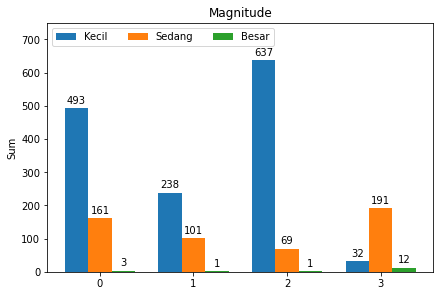

In [133]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

kecil = []
sedang = []
besar = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    kecil.append(kecil_count.get("kecil", 0))
    sedang.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(unique_keys)
category = {
    'Kecil': (kecil),
    'Sedang': (sedang),
    'Besar': (besar),
}

plot_visual(labels, category, "Magnitude", 750)

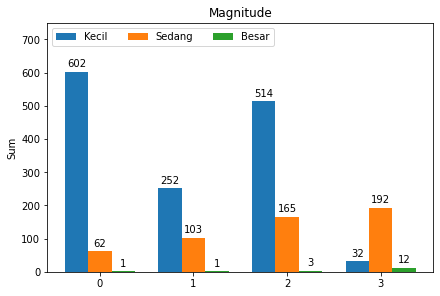

In [134]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

kecil = []
sedang = []
besar = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    kecil.append(kecil_count.get("kecil", 0))
    sedang.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(unique_keys)
category = {
    'Kecil': (kecil),
    'Sedang': (sedang),
    'Besar': (besar),
}

plot_visual(labels, category, "Magnitude", 750)

## Visualisasi kedalaman

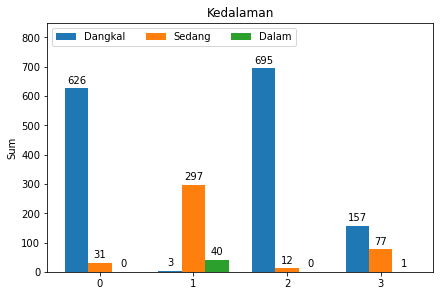

In [135]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 850)

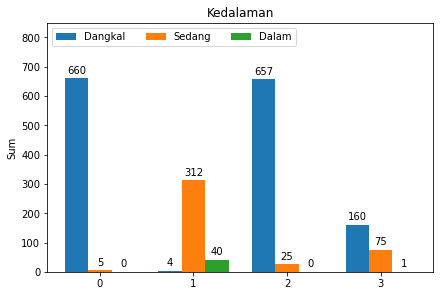

In [136]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 850)

## Visualisasi Jarak

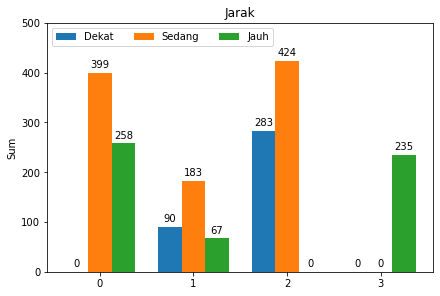

In [137]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

dekat = []
sedang = []
jauh = []

for i in range(4):
    kecil_count = df[(df['kmeans'] == i) & (df['rad_category'] == "dekat")]['rad_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['rad_category'] == "sedang")]['rad_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['rad_category'] == "jauh")]['rad_category'].value_counts()
    
    dekat.append(kecil_count.get("dekat", 0))
    sedang.append(sedang_count.get("sedang", 0))
    jauh.append(besar_count.get("jauh", 0))

labels = np.array(unique_keys)
category = {
    'Dekat': (dekat),
    'Sedang': (sedang),
    'Jauh': (jauh),
}

plot_visual(labels, category, "Jarak", 500)

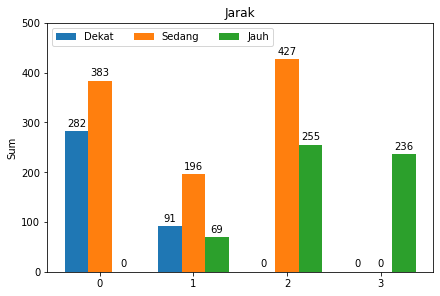

In [138]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

dekat = []
sedang = []
jauh = []

for i in range(4):
    kecil_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "dekat")]['rad_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "sedang")]['rad_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['rad_category'] == "jauh")]['rad_category'].value_counts()
    
    dekat.append(kecil_count.get("dekat", 0))
    sedang.append(sedang_count.get("sedang", 0))
    jauh.append(besar_count.get("jauh", 0))

labels = np.array(unique_keys)
category = {
    'Dekat': (dekat),
    'Sedang': (sedang),
    'Jauh': (jauh),
}

plot_visual(labels, category, "Jarak", 500)

## Export Model

In [139]:
## KMeans Model
# with open('kmeans_model.pkl', 'wb') as file:
#     pickle.dump(kmeans, file)
    
# print("Model saved to kmeans_model.pkl")

In [140]:
# with open('kmedoids_model.pkl', 'wb') as file:
#     pickle.dump(kMedoids, file)
    
# print("Model saved to kmedoids_model.pkl")